# Actividad guiada con pistas: K-Means con el dataset **NYPD Arrest Data**

## Objetivos
1. Explorar el dataset.
2. Seleccionar variables adecuadas para K-Means.
3. Preparar los datos.
4. Escalar las variables.
5. Probar varios valores de `k`.
6. Interpretar los clusters obtenidos.

> Usa las pistas solo si te bloqueas. La idea es que el notebook te ayude, pero que el razonamiento lo hagas tú.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


df = pd.read_csv("NYPD_Arrest_Data__Year_to_Date_.csv", sep=",")

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (278953, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 1. Exploración inicial

### Tarea
Muestra:
- las columnas del dataset,
- los tipos de datos,
- y los valores nulos.

### Responde
- ¿Qué variables parecen útiles para K-Means?
- ¿Qué variables no se pueden usar directamente?


In [64]:
# PISTA:
# - Usa df.columns para ver las columnas
#df.columns
# - Usa df.dtypes para ver los tipos de datos
#df.dtypes
# - Usa df.isna().sum() para ver los valores nulos
df.isna().sum()
# - Si quieres ordenar los nulos: sort_values(ascending=False)
# En mi caso al tener solo 1474 nulos, voy a tirar un dropna
df.dropna(inplace=True)
# Escribe aquí tu código
# Voy a cambiar el Date a DateTime para mas tarde tratar los datos comodamente
df["ARREST_DATE"] = pd.to_datetime(df["ARREST_DATE"], yearfirst=False)

## 2. Crear una variable numérica para la edad

La columna `AGE_GROUP` es categórica.  
Transforma sus categorías en valores numéricos aproximados.

Sugerencia:
- `<18` → 17
- `18-24` → 21
- `25-44` → 34.5
- `45-64` → 54.5
- `65+` → 70


In [65]:
# PISTA:
# 1) Crea un diccionario de equivalencias
df["AGE_GROUP"] = df["AGE_GROUP"].replace({
    "<18": 17,
    "18-24": 21,
    "25-44": 34.5,
    "45-64": 54.5,
    "65+": 70
})
# 2) Usa df["AGE_GROUP"].map(...)
# 3) Guarda el resultado en una nueva columna llamada AGE_NUM
# 4) Si aparecen NaN, revisa si falta alguna categoría en el diccionario

df.isna().sum()["AGE_GROUP"]

# Escribe aquí tu código


np.int64(0)

## 3. Selección de variables

### Tarea
Crea un nuevo DataFrame con estas variables:
- `Latitude`
- `Longitude`
- `ARREST_PRECINCT`
- `JURISDICTION_CODE`
- `AGE_NUM`

Después elimina los valores nulos.


In [66]:
# PISTA:
# - Crea una lista con los nombres de las columnas
lista_columnas = ['Latitude', 'Longitude', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP']

# - Usa df[lista_columnas] para seleccionar
df_seleccionado = df[lista_columnas]
# - Usa dropna() para eliminar filas con nulos
df_seleccionado.dropna(inplace=True)
# Hay celdas las cuales no tienen nulos como tal pero tienen (null), los cuales hay que quitar
df_seleccionado["ARREST_PRECINCT"].replace("(null)", inplace=True)
df_seleccionado["JURISDICTION_CODE"].replace("(null)", inplace=True)
df_seleccionado["AGE_GROUP"].replace("(null)", inplace=True)

# - Comprueba el tamaño antes y después

# Escribe aquí tu código


/tmp/ipykernel_5128/219961093.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seleccionado.dropna(inplace=True)
/tmp/ipykernel_5128/219961093.py:10: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df_seleccionado["ARREST_PRECINCT"].replace("(null)", inplace=True)
/tmp/ipykernel_5128/219961093.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

## 4. Crear una muestra

El dataset es grande.  
Toma una muestra aleatoria de hasta **15.000 filas** para trabajar más rápido.


In [67]:
# PISTA:
# - Usa .sample()
df_sample = df_seleccionado.sample(n=15000, random_state=42)
#df_sample["ARREST_DATEKEY"] = df_sample["ARREST_DATE"]
# - Añade random_state=42 para que siempre salga la misma muestra
# - Puedes hacer algo así:
#   muestra = datos.sample(n=15000, random_state=42)
# - Pero antes conviene comprobar si hay al menos 15000 filas

df_sample.info()
# Escribe aquí tu código


<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 180778 to 278482
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude           15000 non-null  float64
 1   Longitude          15000 non-null  float64
 2   ARREST_PRECINCT    15000 non-null  int64  
 3   JURISDICTION_CODE  15000 non-null  int64  
 4   AGE_GROUP          15000 non-null  object 
dtypes: float64(2), int64(2), object(1)
memory usage: 703.1+ KB


## 5. Escalado

### Tarea
Escala la muestra con `StandardScaler` y guarda el resultado en `X`.

### Responde
- ¿Por qué es necesario escalar antes de aplicar K-Means?
Es necesario escalar en K-Means porque hay que homogeneizar los pesos de todos los datos, ya que no todas las variables tienen el mismo rango de valores.


In [76]:
# PISTA:
# - Crea un objeto StandardScaler()
escalador = StandardScaler()
X = escalador.fit_transform(df_sample)
# - Usa fit_transform() sobre la muestra
# - Guarda el resultado en X
# - K-Means usa distancias, por eso el escalado es importante

# Escribe aquí tu código
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
clusters = kmeans.labels_


## 6. Método del codo y silhouette

### Tarea
Prueba valores de `k` entre 2 y 8.
Para cada uno:
- ajusta un modelo K-Means,
- guarda la inercia,
- calcula el `silhouette_score`.

Después representa ambas métricas en dos gráficas.


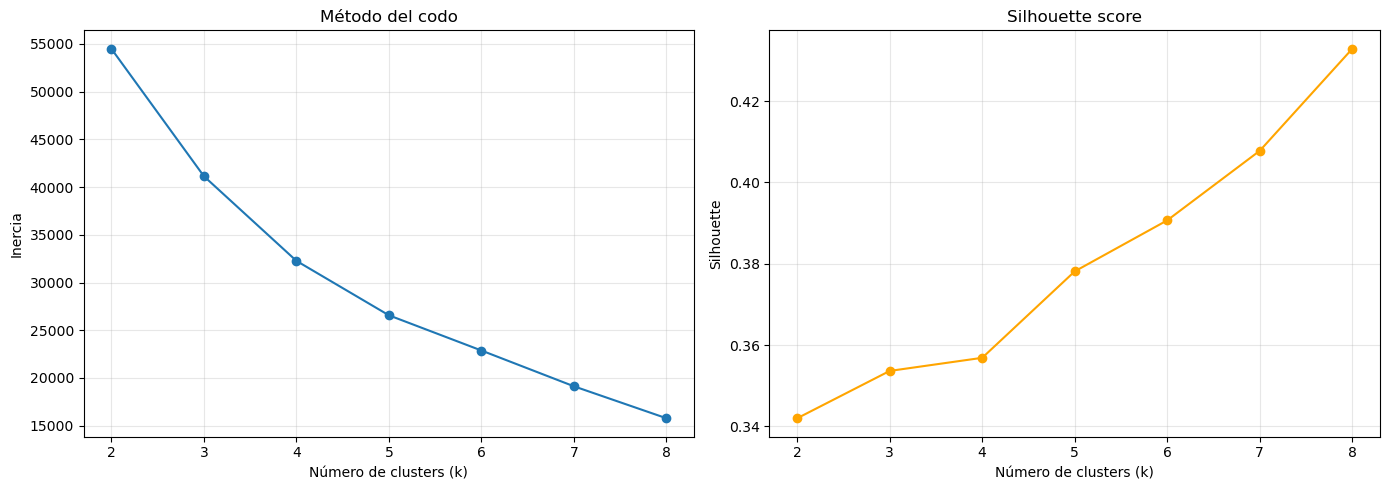

In [79]:
# PISTA:
# - Crea listas vacías: inercias = [] y siluetas = []
# - Recorre varios valores de k con un for
# - En cada vuelta:
#       modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
#       etiquetas = modelo.fit_predict(X)
#       inercias.append(modelo.inertia_)
#       siluetas.append(silhouette_score(X, etiquetas))
# - Después representa ambas listas con plt.plot(...)

# Escribe aquí tu código
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 9)
inercias = []
siluetas = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X, etiquetas))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_values, siluetas, marker="o", color="orange")
plt.title("Silhouette score")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Elección de `k`

### Responde
- ¿Qué valor de `k` te parece más razonable?
- ¿Coinciden el método del codo y la silueta?
- ¿La elección es completamente objetiva?

**Pista conceptual:**  
Busca un equilibrio entre:
- un “codo” visible en la gráfica de inercia,
- y un valor alto de `silhouette_score`.


In [95]:
# Escribe aquí, si quieres, el valor elegido
k_final = 4


## 8. Entrenamiento del modelo final

### Tarea
Entrena el modelo con `k_final` y añade la columna `cluster` al DataFrame de trabajo.


In [96]:
# PISTA:
# - Crea el modelo KMeans con k_final
# - Usa fit_predict(X)
# - Guarda las etiquetas en una variable, por ejemplo: clusters
# - Haz una copia de la muestra y añade una nueva columna llamada cluster

# Escribe aquí tu código
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

resultado = df_sample.copy()
resultado["cluster"] = clusters

resultado.head()

,Latitude,Longitude,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,cluster
180778,40.679981,-73.776234,113,3,54.5,1
222914,40.750991,-73.990623,14,1,54.5,0
269845,40.651116,-73.952517,67,0,21,3
234253,40.652454,-74.009638,72,0,54.5,3
47215,40.606132,-73.752727,101,0,54.5,1


## 9. Visualización de clusters

Representa los clusters con:
- `Longitude` en el eje X
- `Latitude` en el eje Y


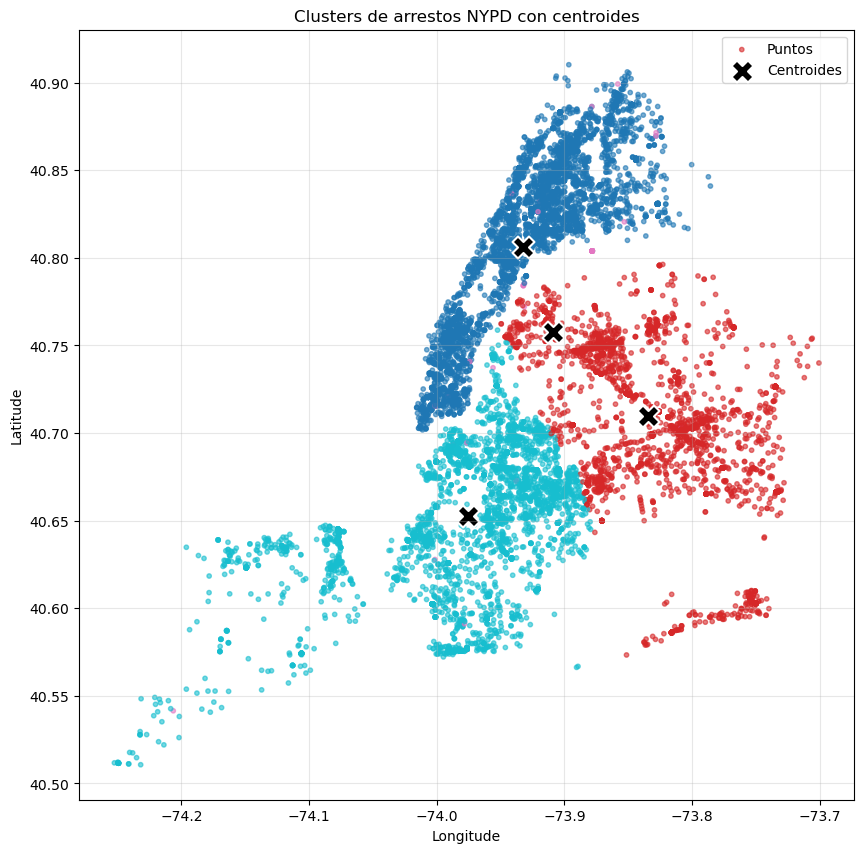

In [97]:
# PISTA:
# - Usa plt.figure(...)
# - Usa plt.scatter(...)
# - En c=... debes indicar la columna de clusters
# - Etiqueta los ejes y añade título

# Ejemplo de idea:
# plt.scatter(resultado["Longitude"], resultado["Latitude"], c=resultado["cluster"])

# Escribe aquí tu código
# Centroides en escala original
centroides_escalados = kmeans_final.cluster_centers_
centroides_originales = escalador.inverse_transform(centroides_escalados)
df_centroides = pd.DataFrame(centroides_originales, columns=df_sample.columns)

plt.figure(figsize=(10, 10))
plt.scatter(
    resultado["Longitude"],
    resultado["Latitude"],
    c=resultado["cluster"],
    cmap="tab10",
    s=10,
    alpha=0.6,
    label="Puntos"
)

plt.scatter(
    df_centroides["Longitude"],
    df_centroides["Latitude"],
    c="black",
    s=250,
    marker="X",
    edgecolors="white",
    linewidths=1.5,
    label="Centroides"
)

plt.title("Clusters de arrestos NYPD con centroides")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 10. Centroides en escala original

### Tarea
- Obtén los centroides del modelo.
- Transfórmalos de nuevo a la escala original.
- Muéstralos en un DataFrame.


In [98]:
# PISTA:
# - Los centroides del modelo están en kmeans.cluster_centers_
# - Están escalados, así que hay que usar scaler.inverse_transform(...)
# - Después puedes convertir el resultado en DataFrame con las columnas originales

# Escribe aquí tu código
centroides_escalados = kmeans_final.cluster_centers_
centroides_originales = escalador.inverse_transform(centroides_escalados)

df_centroides = pd.DataFrame(centroides_originales, columns=df_sample.columns)
df_centroides

,Latitude,Longitude,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP
0,40.806297,-73.932622,31.247922,0.375383,37.127242
1,40.709495,-73.834435,104.891127,0.473438,37.469206
2,40.757784,-73.908984,54.848485,74.565657,37.000000
3,40.652824,-73.975221,79.848419,0.286055,37.362386


## 11. Interpretación final

### Responde brevemente
1. ¿Qué patrón general observas en los clusters?
2. ¿Qué variables parecen influir más?
3. ¿Qué limitaciones tiene K-Means en este dataset?
4. ¿Qué otro algoritmo podría funcionar mejor y por qué?

**Pistas de reflexión:**
- ¿Los grupos parecen zonas geográficas?
- ¿K-Means funciona bien con distribuciones irregulares?
- ¿Qué ocurre con las variables categóricas?
- ¿Te parecería mejor DBSCAN para datos espaciales?


In [99]:
# Puedes escribir aquí tus conclusiones en comentarios
# o crear una celda Markdown nueva debajo.

# 1. Los clusters parecen reflejar zonas geograficas y diferencias entre precincts/jurisdiction.
# 2. Las variables que mas influyen probablemente son Latitude, Longitude y ARREST_PRECINCT.
# 3. K-Means tiene limitaciones porque asume grupos mas o menos esfericos y trabaja regular con datos espaciales irregulares.
# 4. DBSCAN podria funcionar mejor en este caso, porque detecta mejor agrupaciones espaciales y ruido.